In [ ]:
import pandas as pd

#file_path = "../Data/stresstest1_train/training_data.csv"
file_path = "../Data/stresstest2/training_data_improved_2.csv"

df = pd.read_csv(file_path, sep=';')

odd_phases = [1,3,5,7,9,11]
even_phases = [2,4,6,8,10,12]

# Beräkna om klassificeringen är korrekt
def is_correct(row):

    phase = row["Experiment_Phase"]
    pred = row["baseline_classification"]
    # pred = row["improved_classification"]

    # Förväntat: 1 eller 2
    if phase in odd_phases:
        return 1 if pred in [1,2] else 0

    # Förväntat: 0
    elif phase in even_phases:
        return 1 if pred == 0 else 0

    return None

df["correct"] = df.apply(is_correct, axis=1)

# Ta bort phase 0 om den finns
df_eval = df[df["correct"].notna()]

# Total accuracy
accuracy = df_eval["correct"].mean()

print(f"Total accuracy: {accuracy:.2%}")

Total accuracy: 52.25%


In [2]:
phase_accuracy = (
    df_eval.groupby("Experiment_Phase")["correct"]
    .mean()
    .reset_index()
)

print(phase_accuracy)

    Experiment_Phase  correct
0                  1      0.0
1                  2      1.0
2                  3      0.0
3                  4      1.0
4                  5      0.0
5                  6      1.0
6                  7      0.0
7                  8      1.0
8                  9      0.0
9                 10      1.0
10                11      0.0
11                12      1.0


In [4]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv(file_path, sep=';')

y_true = df["ground_truth"]
y_pred = df ["improved_classification"]  # Ändra till "baseline_classification" för baseline-resultat
# y_pred = df["baseline_classification"]

accuracy = accuracy_score(y_true, y_pred)

print("Accuracy:", accuracy)

print(classification_report(y_true, y_pred))

Accuracy: 0.5909090909090909
              precision    recall  f1-score   support

           0       0.59      1.00      0.74        78
           1       0.00      0.00      0.00        54

    accuracy                           0.59       132
   macro avg       0.30      0.50      0.37       132
weighted avg       0.35      0.59      0.44       132



c:\Users\pat19\OneDrive\Skrivbord\Thesis\CLAS_SOM_project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pat19\OneDrive\Skrivbord\Thesis\CLAS_SOM_project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pat19\OneDrive\Skrivbord\Thesis\CLAS_SOM_project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this b

In [6]:
import pandas as pd

df = pd.read_csv(file_path, sep=';')

# Exempel features
features = [
    "HR",
    "RMSSD",
    "SC_PH",
    "SC_RR"
]

for col in features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
# Mean per phase
mean_features = (
    df.groupby("Experiment_Phase")[features]
    .mean()
)

print(mean_features)

                         HR      RMSSD     SC_PH     SC_RR
Experiment_Phase                                          
0                 69.107832  55.781352  0.001129  0.025362
1                 68.551565  42.195729  0.001256  0.037037
2                 65.542044  51.951820  0.001225  0.040000
3                 66.980187  37.566305  0.000953  0.025926
4                 64.257125  51.931352  0.000643  0.005556
5                 66.072657  35.203015  0.000207  0.000000
6                 57.042452  60.214723  0.000583  0.006667
7                 63.069771  60.442766  0.000468  0.000000
8                 58.189700  54.080925  0.000206  0.000000
9                 62.805607  58.390985  0.000178  0.000000
10                59.720333  61.843804  0.000137  0.000000
11                58.580728  58.404712  0.000241  0.000000
12                58.963363  57.745942  0.000151  0.000000


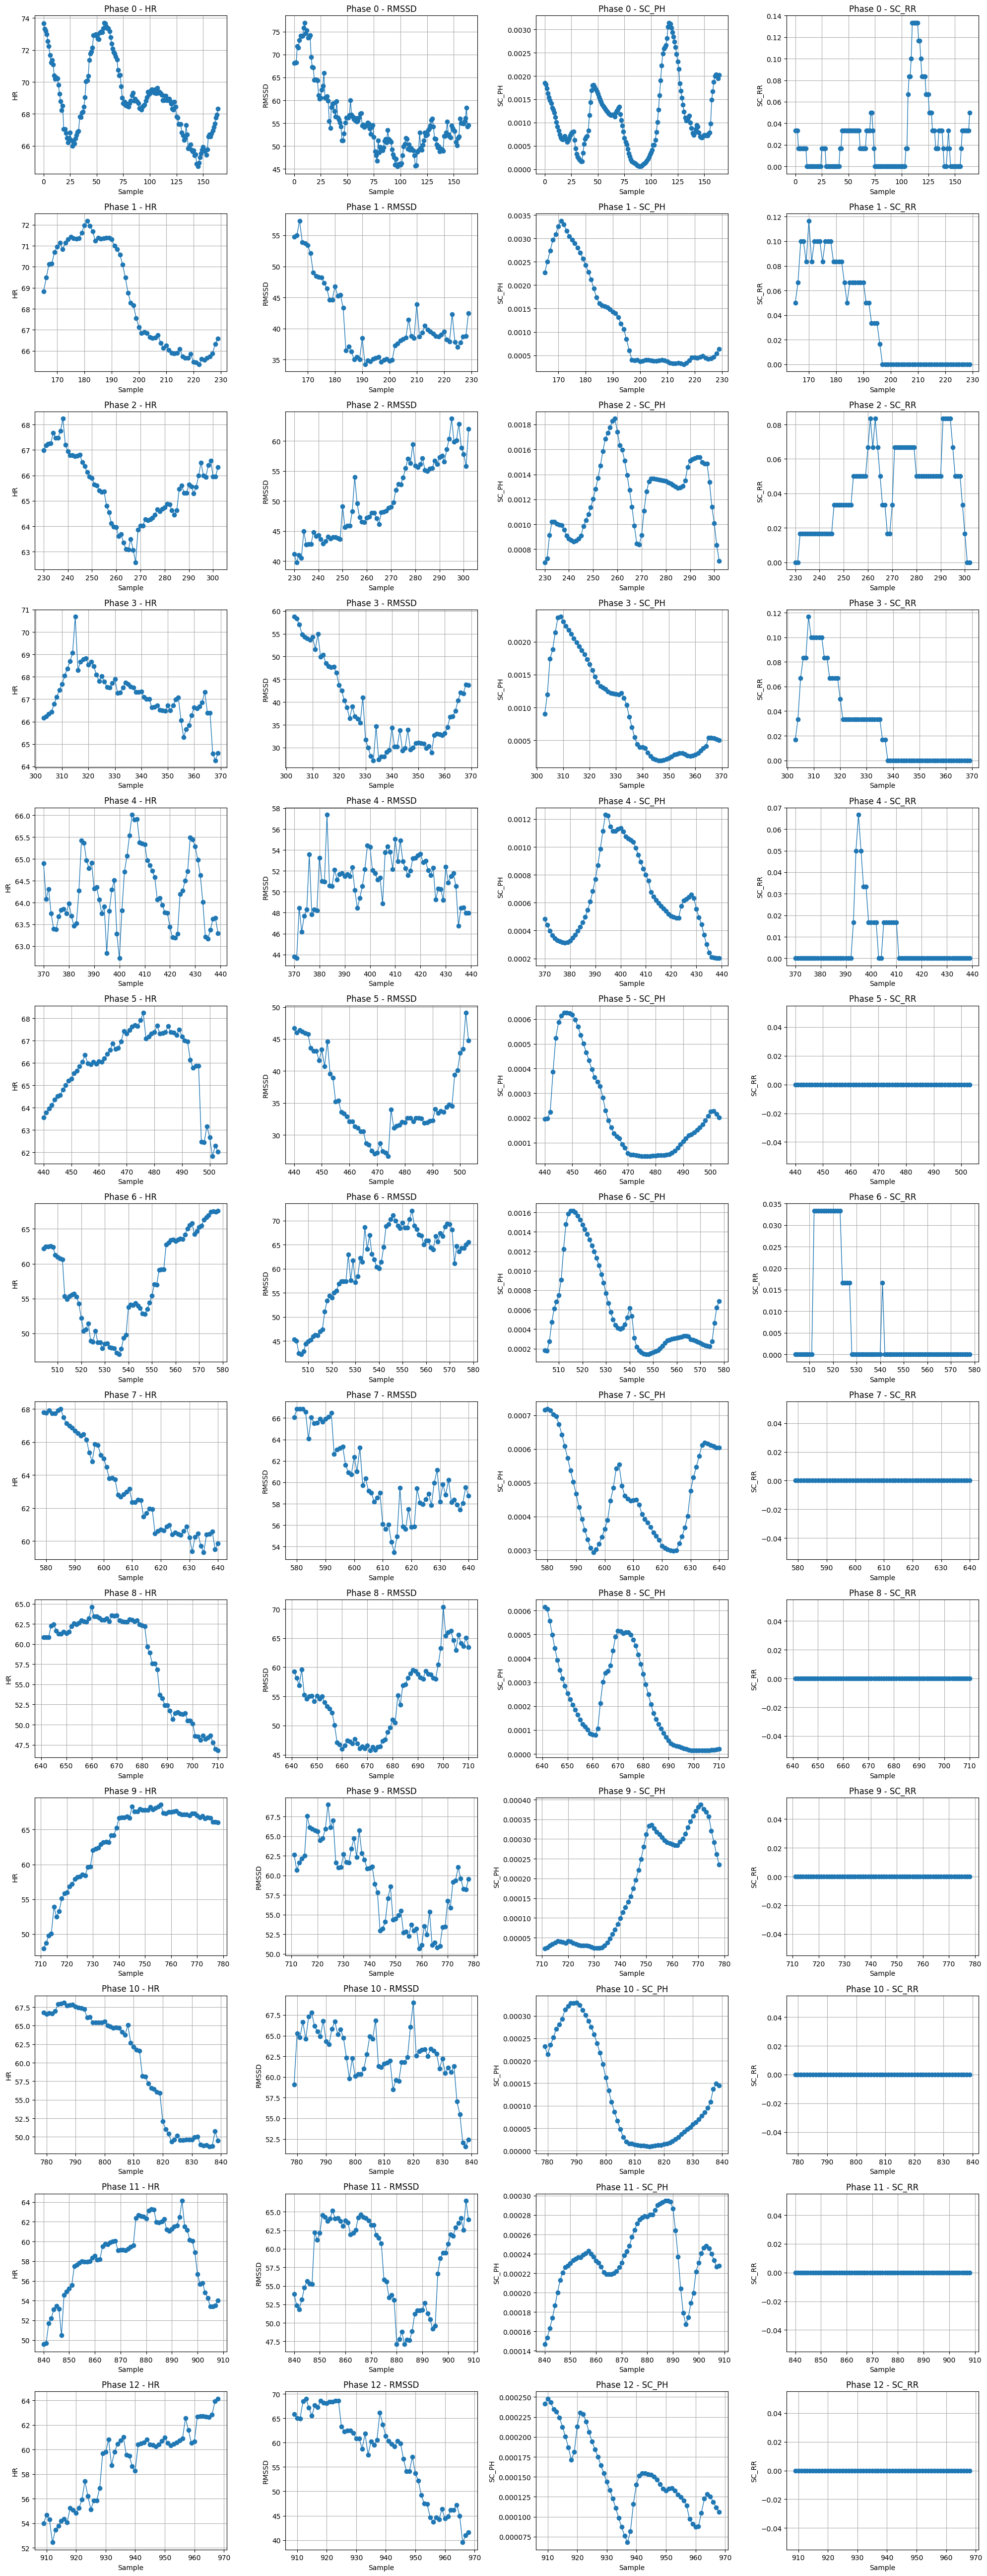

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Läs CSV
df = pd.read_csv(file_path, sep=';')

# Rensa kolumnnamn
df.columns = df.columns.str.strip()

# Features
features = ["HR", "RMSSD", "SC_PH", "SC_RR"]

# Konvertera till numeriska värden
for col in features + ["Experiment_Phase"]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Alla phases
phases = sorted(df["Experiment_Phase"].dropna().unique())

# ===== EN RAD PER PHASE =====
# Varje rad = en phase
# 4 plots per rad (HR, RMSSD, SC_PH, SC_RR)

fig, axes = plt.subplots(
    nrows=len(phases),
    ncols=4,
    figsize=(20, 4 * len(phases))
)

# Om bara en phase finns
if len(phases) == 1:
    axes = [axes]

for row_idx, phase in enumerate(phases):

    # Filtrera aktuell phase
    phase_data = df[df["Experiment_Phase"] == phase]

    for col_idx, feature in enumerate(features):

        ax = axes[row_idx][col_idx]

        # Plot feature-värden över samples/block
        ax.plot(
            phase_data.index,
            phase_data[feature],
            marker='o',
            linewidth=1
        )

        ax.set_title(f"Phase {phase} - {feature}")
        ax.set_xlabel("Sample")
        ax.set_ylabel(feature)

        ax.grid(True)

# Snygg layout
plt.tight_layout()

# Visa
plt.show()


 OCCUPANCY PER PHASE 

cluster             0
Experiment_Phase     
0                 1.0
1                 1.0
2                 1.0
3                 1.0
4                 1.0
5                 1.0
6                 1.0
7                 1.0
8                 1.0
9                 1.0
10                1.0
11                1.0
12                1.0

 TRANSITION MATRIX 

     0
0  1.0


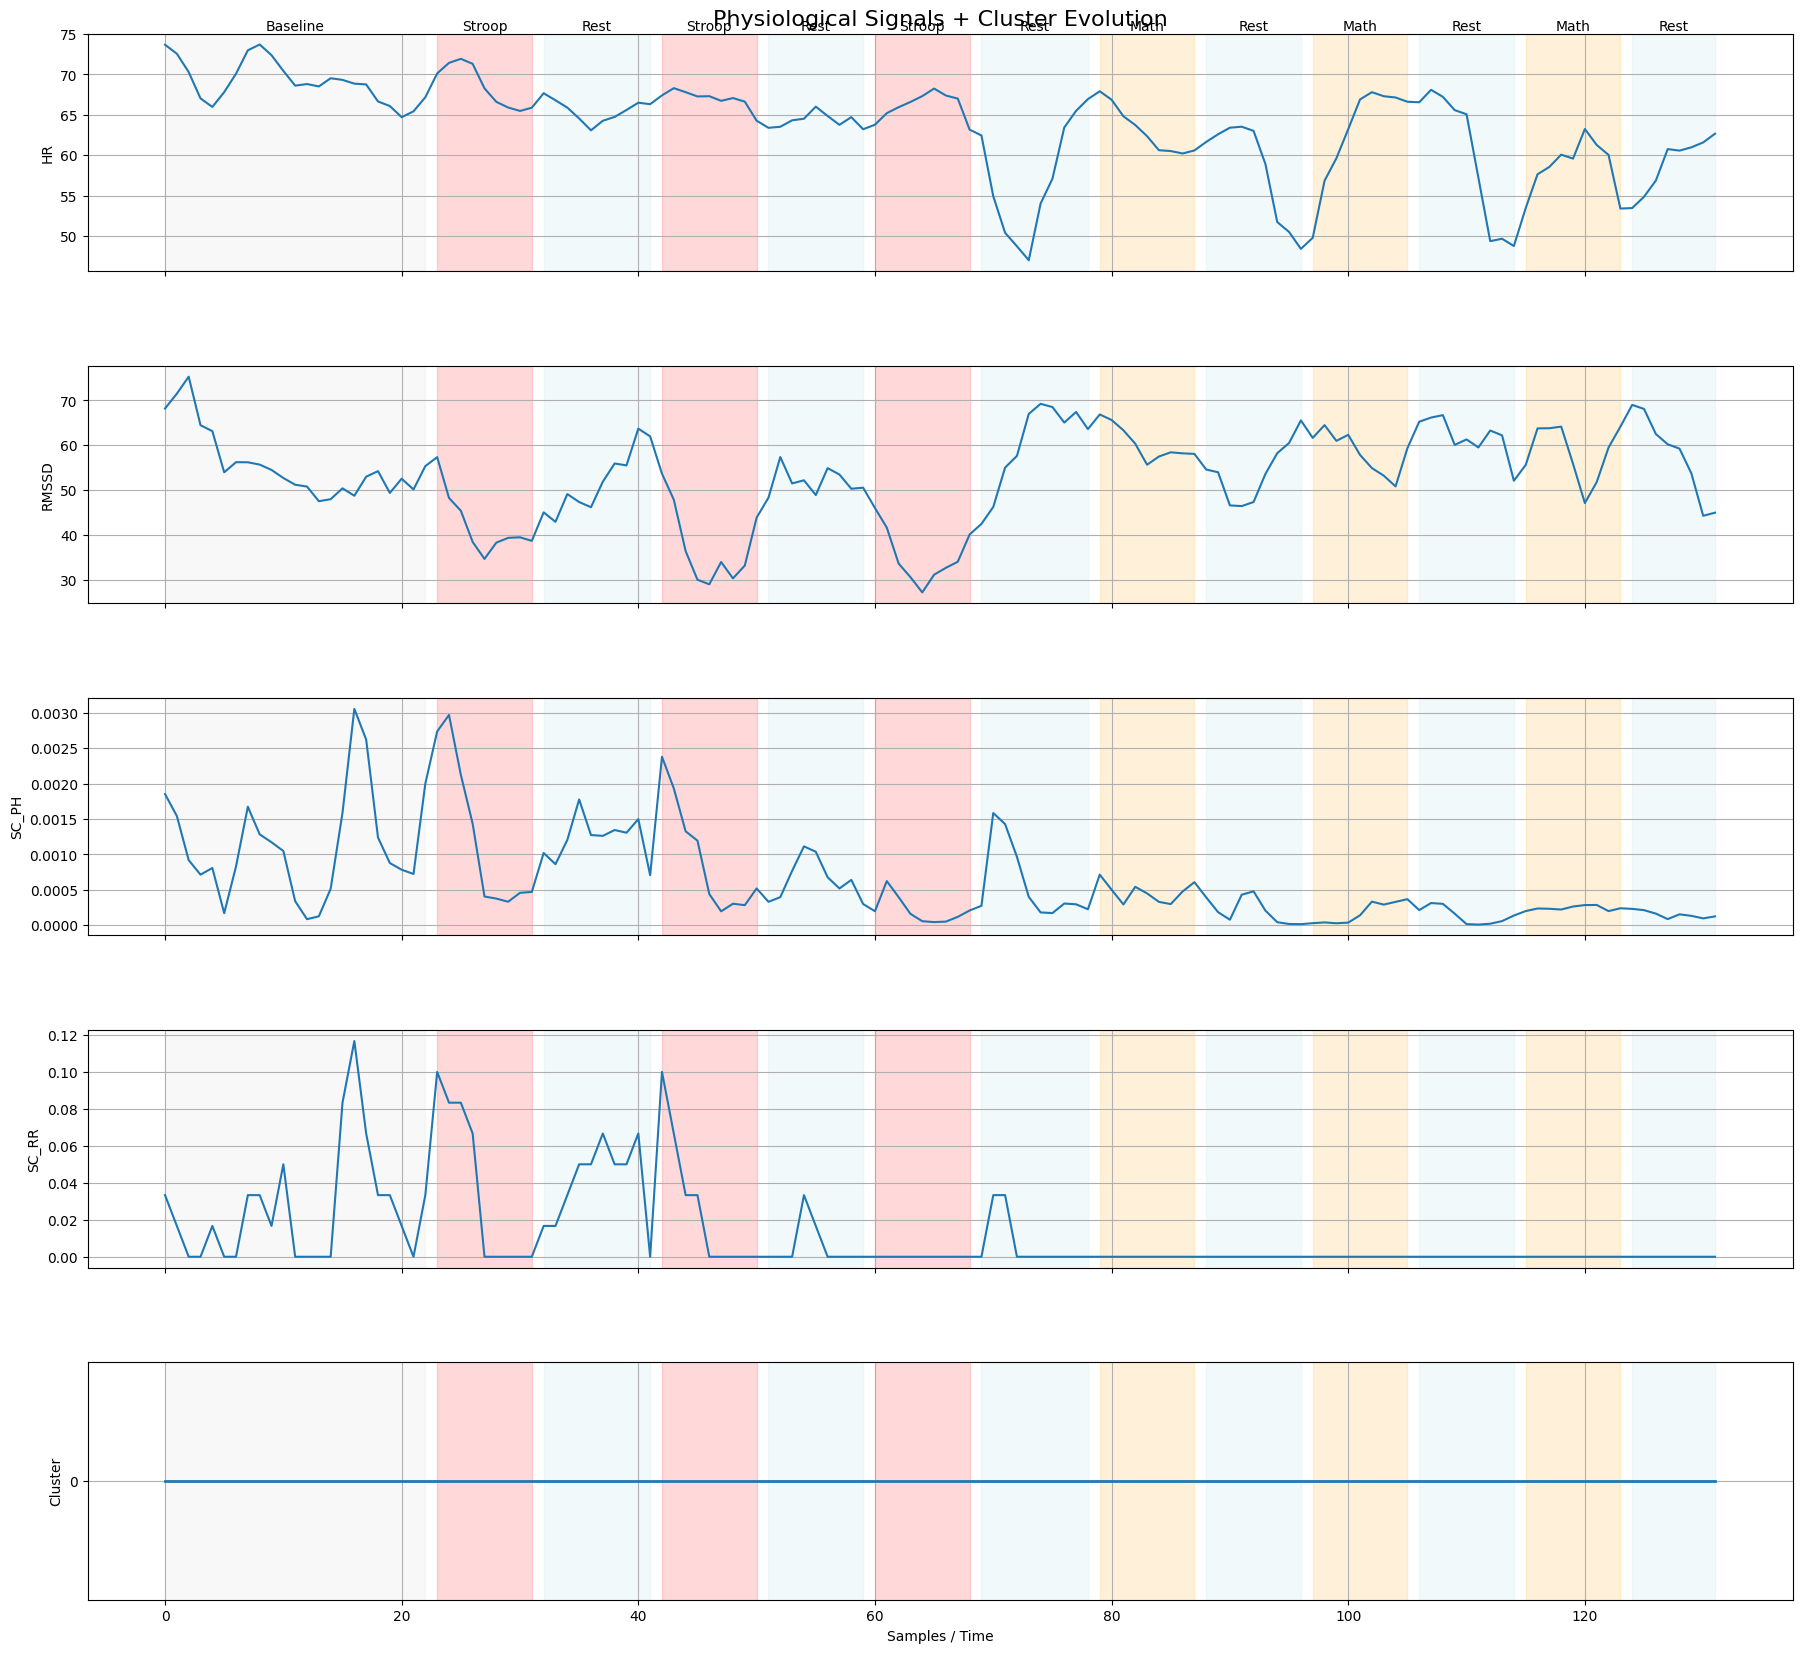

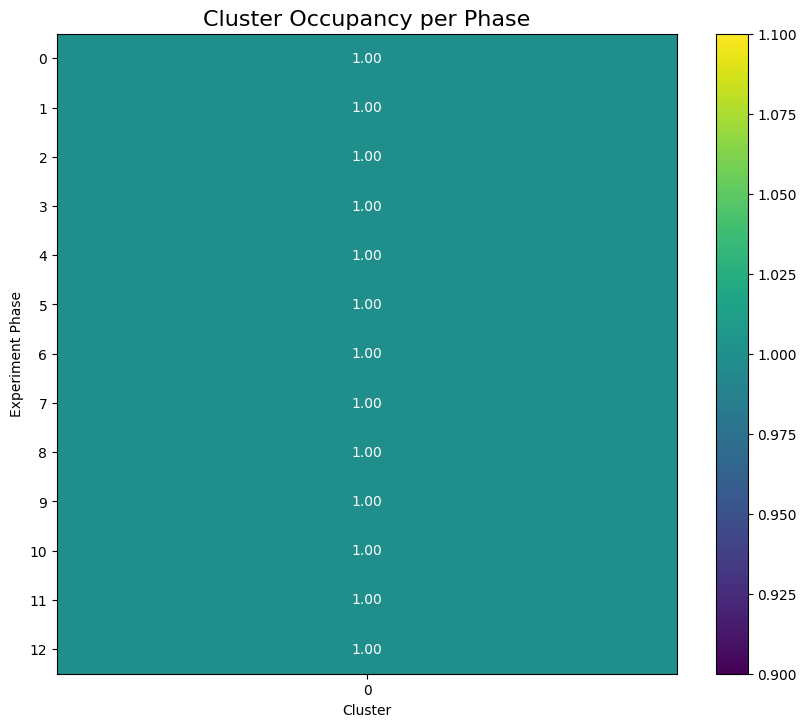

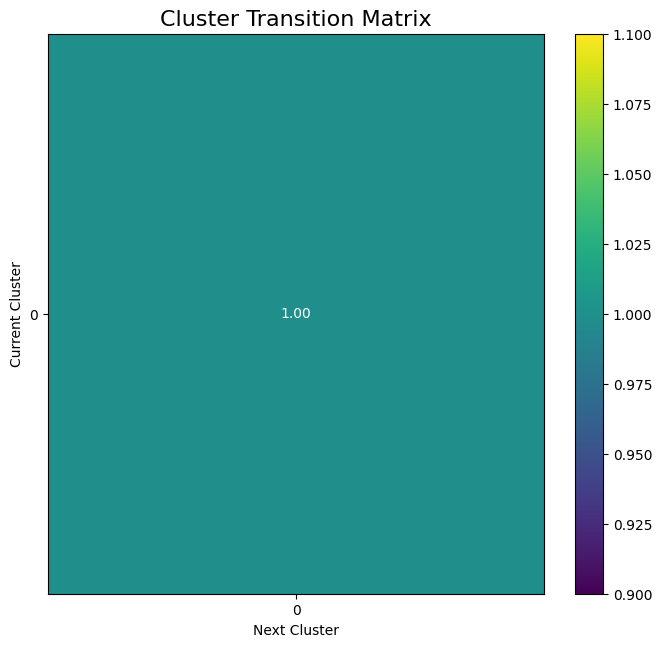

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# ==========================================
# LÄS CSV
# ==========================================

df = pd.read_csv(file_path, sep=';')

# ==========================================
# RENSA KOLUMNNAMN
# ==========================================

df.columns = (
    df.columns
    .str.strip()
    .str.replace('\ufeff', '', regex=False)
)

# ==========================================
# NUMERISKA KOLUMNER
# ==========================================

numeric_cols = [
    "HR",
    "RMSSD",
    "SC_PH",
    "SC_RR",
    "Experiment_Phase",
    "improved_classification",
    "ground_truth"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ==========================================
# DEFINIERA CLUSTER
# ==========================================

df["cluster"] = df["improved_classification"]

# ==========================================
# PHASE COLORS
# ==========================================

phase_colors = {
    0: 'lightgray',
    1: 'red',
    2: 'lightblue',
    3: 'red',
    4: 'lightblue',
    5: 'red',
    6: 'lightblue',
    7: 'orange',
    8: 'lightblue',
    9: 'orange',
    10: 'lightblue',
    11: 'orange',
    12: 'lightblue'
}

phase_labels = {
    0: 'Baseline',
    1: 'Stroop',
    2: 'Rest',
    3: 'Stroop',
    4: 'Rest',
    5: 'Stroop',
    6: 'Rest',
    7: 'Math',
    8: 'Rest',
    9: 'Math',
    10: 'Rest',
    11: 'Math',
    12: 'Rest'
}

# =========================================================
# FIGURE 1 — PHYSIOLOGICAL SIGNALS + CLUSTER EVOLUTION
# =========================================================

fig1, axes = plt.subplots(
    5,
    1,
    figsize=(22, 18),
    sharex=True
)

signals = ["HR", "RMSSD", "SC_PH", "SC_RR"]

for i, signal in enumerate(signals):

    axes[i].plot(
        df.index,
        df[signal],
        linewidth=1.5
    )

    axes[i].set_ylabel(signal)
    axes[i].grid(True)

# ==========================================
# CLUSTER EVOLUTION
# ==========================================

axes[4].plot(
    df.index,
    df["cluster"],
    drawstyle='steps-post',
    linewidth=2
)

axes[4].set_ylabel("Cluster")
axes[4].set_yticks(sorted(df["cluster"].dropna().unique()))
axes[4].grid(True)

# ==========================================
# PHASE BACKGROUND
# ==========================================

for phase in sorted(df["Experiment_Phase"].dropna().unique()):

    phase_data = df[df["Experiment_Phase"] == phase]

    start = phase_data.index.min()
    end = phase_data.index.max()

    for ax in axes:

        ax.axvspan(
            start,
            end,
            color=phase_colors.get(phase, 'gray'),
            alpha=0.15
        )

    axes[0].text(
        (start + end) / 2,
        axes[0].get_ylim()[1],
        phase_labels.get(phase, str(phase)),
        ha='center',
        va='bottom',
        fontsize=10
    )

axes[0].set_title(
    "Physiological Signals + Cluster Evolution",
    fontsize=16
)

axes[-1].set_xlabel("Samples / Time")

fig1.subplots_adjust(
    hspace=0.4,
    top=0.93,
    bottom=0.06
)

# =========================================================
# FIGURE 2 — OCCUPANCY PER PHASE
# =========================================================

occupancy = pd.crosstab(
    df["Experiment_Phase"],
    df["cluster"],
    normalize='index'
)

fig2, ax2 = plt.subplots(figsize=(10, 8))

im1 = ax2.imshow(
    occupancy,
    aspect='auto'
)

ax2.set_title(
    "Cluster Occupancy per Phase",
    fontsize=16
)

ax2.set_ylabel("Experiment Phase")
ax2.set_xlabel("Cluster")

ax2.set_yticks(range(len(occupancy.index)))
ax2.set_yticklabels(occupancy.index)

ax2.set_xticks(range(len(occupancy.columns)))
ax2.set_xticklabels(occupancy.columns)

# Skriv värden i heatmap
for i in range(len(occupancy.index)):
    for j in range(len(occupancy.columns)):

        value = occupancy.iloc[i, j]

        ax2.text(
            j,
            i,
            f"{value:.2f}",
            ha='center',
            va='center',
            color='white'
        )

plt.colorbar(im1, ax=ax2)

fig2.subplots_adjust(
    top=0.9,
    bottom=0.1
)

# =========================================================
# FIGURE 3 — TRANSITION MATRIX
# =========================================================

clusters = df["cluster"].dropna().astype(int).values

transitions = Counter()

for i in range(len(clusters)-1):

    current_cluster = clusters[i]
    next_cluster = clusters[i+1]

    transitions[(current_cluster, next_cluster)] += 1

unique_clusters = sorted(df["cluster"].dropna().unique())

transition_matrix = pd.DataFrame(
    0,
    index=unique_clusters,
    columns=unique_clusters
)

for (c1, c2), count in transitions.items():

    transition_matrix.loc[c1, c2] = count

# Normalisera radvis
transition_matrix = transition_matrix.div(
    transition_matrix.sum(axis=1),
    axis=0
)

fig3, ax3 = plt.subplots(figsize=(8, 7))

im2 = ax3.imshow(
    transition_matrix,
    aspect='auto'
)

ax3.set_title(
    "Cluster Transition Matrix",
    fontsize=16
)

ax3.set_xlabel("Next Cluster")
ax3.set_ylabel("Current Cluster")

ax3.set_xticks(range(len(unique_clusters)))
ax3.set_xticklabels(unique_clusters)

ax3.set_yticks(range(len(unique_clusters)))
ax3.set_yticklabels(unique_clusters)

# Skriv värden i heatmap
for i in range(len(unique_clusters)):
    for j in range(len(unique_clusters)):

        value = transition_matrix.iloc[i, j]

        ax3.text(
            j,
            i,
            f"{value:.2f}",
            ha='center',
            va='center',
            color='white'
        )

plt.colorbar(im2, ax=ax3)

fig3.subplots_adjust(
    top=0.9,
    bottom=0.1
)

# =========================================================
# PRINT TABLES
# =========================================================

print("\n==============================")
print(" OCCUPANCY PER PHASE ")
print("==============================\n")

print(occupancy)

print("\n==============================")
print(" TRANSITION MATRIX ")
print("==============================\n")

print(transition_matrix)

# =========================================================
# SHOW
# =========================================================

plt.show()